# Compare-Map Visualisations

This notebook loads a `metrics.jsonl` generated by `nas/compare-track.py`,
builds a table where rows are architectures and columns are maps, and then
plots the RMSEs so different planners can be compared at a glance.

Adjust the `RUN_DIR` value in the next cell if you want to point at a specific
run directory under `nas/compare-map/`. By default it selects the newest one.


In [97]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

try:
    BASE_OUTPUT_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_OUTPUT_DIR = Path.cwd()


def latest_run_dir(base_dir: Path = BASE_OUTPUT_DIR) -> Path:
    candidates = sorted(
        [path for path in base_dir.glob("*/metrics.jsonl")],
        key=lambda p: p.stat().st_mtime,
    )
    if not candidates:
        raise FileNotFoundError(
            f"No metrics.jsonl files found under {base_dir}. Run nas/compare-track.py first."
        )
    return candidates[-1].parent

RUN_DIR_OVERRIDE: Path | str | None = "compare_20260416T134034"  # e.g., "compare_20260410T133741"
# RUN_DIR_OVERRIDE: Path | str | None = None


def resolve_run_dir() -> Path:
    if RUN_DIR_OVERRIDE:
        candidate = Path(RUN_DIR_OVERRIDE)
        if not candidate.is_absolute():
            candidate = BASE_OUTPUT_DIR / candidate
        if candidate.is_file():
            candidate = candidate.parent
        if not candidate.exists():
            raise FileNotFoundError(
                f"Override directory {candidate} was not found. Update RUN_DIR_OVERRIDE."
            )
        metrics_file = candidate / "metrics.jsonl"
        if not metrics_file.exists():
            raise FileNotFoundError(
                f"{metrics_file} was not found; choose a directory containing metrics.jsonl."
            )
        return candidate
    return latest_run_dir()

RUN_DIR = resolve_run_dir()
METRICS_FILE = RUN_DIR / "metrics.jsonl"
print(f"Using metrics from: {RUN_DIR}")

with METRICS_FILE.open("r", encoding="utf-8") as fh:
    METRIC_RECORDS = [json.loads(line) for line in fh if line.strip()]

if not METRIC_RECORDS:
    raise RuntimeError(f"{METRICS_FILE} is empty; rerun compare-track.")

rows: list[dict[str, object]] = []
for record in METRIC_RECORDS:
    map_name = record["map"]
    for run in record["runs"]:
        rows.append(
            {
                "map": map_name,
                "arch": run["label"],
                "rmse": run.get("rmse"),
            }
        )

df = pd.DataFrame(rows)
pivot = df.pivot_table(index="arch", columns="map", values="rmse")
pivot = pivot.sort_index()
print(f"Loaded RMSE table with shape {pivot.shape} (arches x maps).")


Using metrics from: /Users/zayahcortright/DAX.nosync/f1tenth_ng_zc/nas/compare-map/compare_20260416T134034
Loaded RMSE table with shape (8, 7) (arches x maps).


## RMSE table

Rows correspond to planner architectures; columns are maps. Each cell contains the
cross-track RMSE (in metres) reported by the simulator.


In [98]:
display(
    pivot.style
    .format("{:.4f}")
    .background_gradient(axis=0, cmap="YlGnBu")
    .set_properties(**{"text-align": "center"})
)


map,F1/MexicoCity/MexicoCity,F1/Monza/Monza,F1/Nuerburgring/Nuerburgring,F1/Shanghai/Shanghai,F1/Silverstone/Silverstone,F1/Sochi/Sochi,F1/Spa/Spa
arch,,,,,,,
arch1,0.1337,0.0934,0.0938,0.1375,0.0927,0.1027,0.0910
arch2,0.1243,0.0930,0.1000,0.1376,0.0946,0.0869,0.0913
arch3,0.1480,0.0887,0.1082,0.1658,0.0933,0.1231,0.0816
arch4,0.1477,0.0929,0.1444,0.1668,0.1225,0.1242,0.1083
arch5,0.1396,0.0970,0.1404,0.1599,0.1294,0.1231,0.1183
arch6,0.1355,0.0976,0.1386,0.1492,0.1318,0.1245,0.1180
arch7,0.1412,0.0984,0.1422,0.1727,0.1282,0.1210,0.1152
arch8,0.1340,0.0856,0.1616,0.1972,0.1229,0.1082,0.1130


## Connected RMSE comparison

A connected scatter plot (line plot with markers) makes it easy to see trends
per architecture: each line tracks an arch across maps, so you can spot where
one suddenly performs better or worse relative to the others. The x-axis
reflects each map explicitly so every point sits exactly on its label.


/var/folders/9f/p8vn09k9549gm38xbt1msrc00000gn/T/ipykernel_65293/2792160784.py:48: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


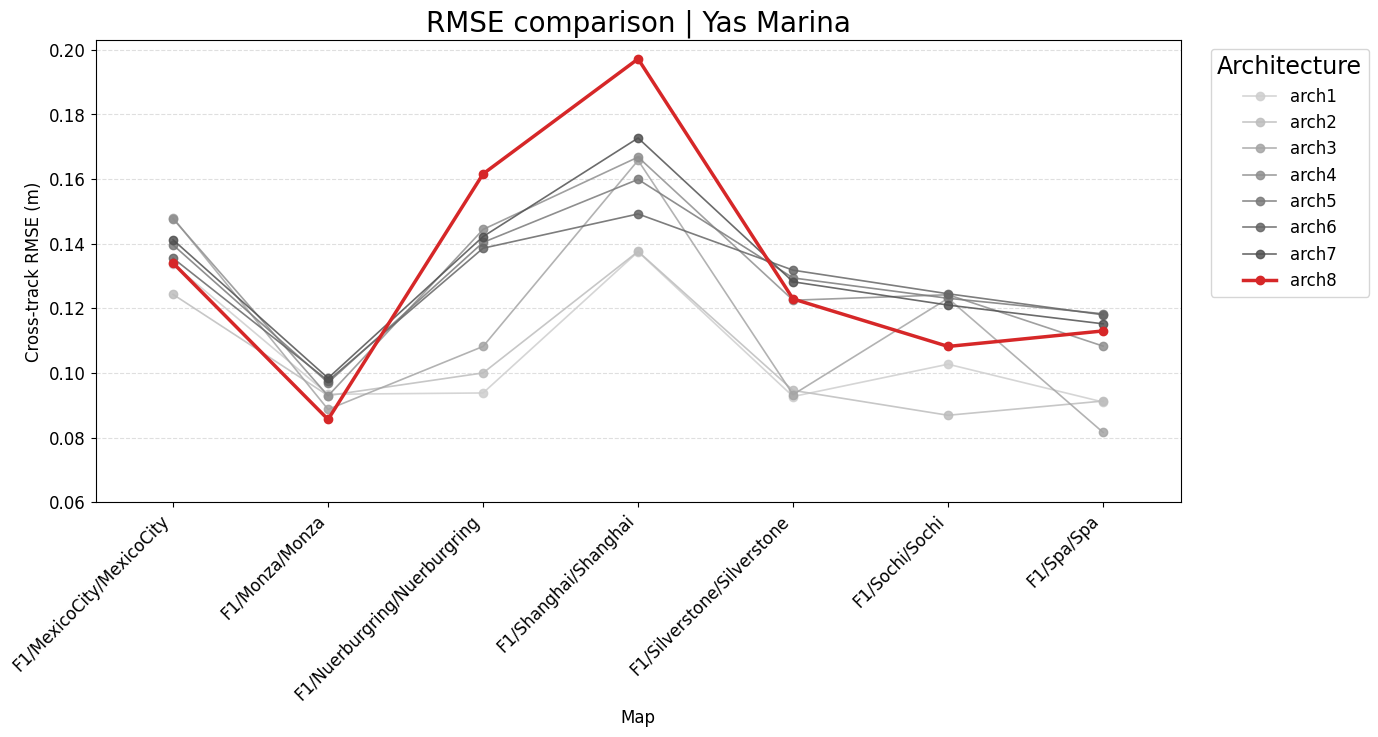

In [99]:
maps = list(pivot.columns)
x_positions = range(len(maps))
highlight_arch = "arch8"
has_highlight = highlight_arch in pivot.index
fig, ax = plt.subplots(figsize=(14, 6))
other_arches = [arch for arch in pivot.index if not (has_highlight and arch == highlight_arch)]
if other_arches:
    muted_scale = np.linspace(0.3, 0.75, len(other_arches))
    for scale, arch in zip(muted_scale, other_arches):
        color = plt.cm.Greys(scale)
        ax.plot(
            x_positions,
            pivot.loc[arch].values,
            marker="o",
            linewidth=1.2,
            color=color,
            alpha=0.85,
            label=arch,
        )
if has_highlight:
    ax.plot(
        x_positions,
        pivot.loc[highlight_arch].values,
        marker="o",
        linewidth=2.5,
        color="#d62728",
        label=highlight_arch,
    )
ax.set_xticks(list(x_positions))
ax.set_xticklabels(maps, rotation=45, ha="right")
ax.set_xlim(-0.5, len(maps) - 0.5)
ax.set_ylabel("Cross-track RMSE (m)")
ax.set_xlabel("Map")
# ax.set_title(f"RMSE comparison across maps ({RUN_DIR.name})")
ax.set_title(f"RMSE comparison | Yas Marina")
ax.set_ylim(bottom=0.06)
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Architecture", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.rcParams.update({
    "font.size": 122,
    "axes.titlesize": 20,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "legend.title_fontsize": 17,
})
plt.tight_layout()
plt.show()
